In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import statsmodels.formula.api as smf
import statsmodels.stats.multitest as smm
from statsmodels.robust.scale import mad
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

from scipy.stats import spearmanr
from scipy import stats

from multiprocessing import Pool

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [2]:
Meta = pd.read_csv("../data/Mendizabal.Metadata.csv", index_col=0)

In [3]:
Data_raw = pd.read_csv("../data/Mendizabal.Raw.csv", index_col=0)
Data_filtered = Data_raw.loc[:, Data_raw.mean() >= 10]

# pyDeSeq2

In [4]:
inference = DefaultInference(n_cpus=16)

dds = DeseqDataSet(
    counts=Data_filtered,
    metadata=Meta,
    design_factors=['Diagnosis', 'Hemisphere'],
    continuous_factors=['Age'],
    refit_cooks=True,
    inference=inference,
)

In [5]:
dds.deseq2()

Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 3.91 seconds.

Fitting dispersion trend curve...
... done in 0.64 seconds.

Fitting MAP dispersions...
... done in 4.55 seconds.

Fitting LFCs...
... done in 2.97 seconds.

Refitting 0 outliers.



In [6]:
dds.vst()

Fitting dispersions...
... done in 2.98 seconds.

Fitting dispersion trend curve...
... done in 0.61 seconds.



In [7]:
Deseq_counts = pd.DataFrame(dds.layers['normed_counts'], index=Data_filtered.index, columns = Data_filtered.columns)

In [8]:
Deseq_counts.to_csv('../data/Mendizabal.pyDeSeq2.csv')

In [9]:
Vst_counts = pd.DataFrame(dds.layers['vst_counts'], index=Data_filtered.index, columns = Data_filtered.columns)

In [10]:
Vst_counts.to_csv('../data/Mendizabal.pyDeSeq2.vst.csv')

In [11]:
stat = DeseqStats(dds, contrast=["Diagnosis", "SZ", "CTL"], inference=inference)
stat.summary()

Running Wald tests...
... done in 1.54 seconds.



Log2 fold change & Wald test p-value: Diagnosis SZ vs CTL
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
653635        46.925212       -1.496393  0.358076 -4.178985  0.000029   
100996442     43.372580       -0.491489  0.181257 -2.711565  0.006697   
729737        32.077971       -1.123440  0.351651 -3.194754  0.001399   
102723897     42.785837       -1.368659  0.365747 -3.742096  0.000182   
112268260     16.051022       -0.027731  0.205709 -0.134810  0.892762   
...                 ...             ...       ...       ...       ...   
4541       97398.574694        1.731099  0.515443  3.358468  0.000784   
4556        8310.550958        1.385422  0.490245  2.825981  0.004714   
4519       37600.653081        1.073779  0.440646  2.436828  0.014817   
4576          62.801360        1.261085  0.532533  2.368087  0.017880   
4571         344.171437        1.123195  0.464598  2.417562  0.015625   

               padj  
653635     0.008469  
100996442  0.059265  

In [12]:
stat.results_df.to_csv('../results/DEGs.Diagnosis.csv')

# Gene selection

In [13]:
Corr = Vst_counts.corrwith(Meta.Age)

In [14]:
Preselected_counts = Vst_counts[Corr[Corr.abs() > 0.3].index].copy()

In [15]:
Preselected_counts.columns = 'ENCODE_ID_' + Preselected_counts.columns.astype(str)
Preselected_counts.index.name = 'individualID'
Meta.index.name = 'individualID'

In [16]:
df = Preselected_counts.merge(Meta[['Age', 'Diagnosis',]], on='individualID', how='left')


gene= 'ENCODE_ID_6146'

model = smf.ols(formula=f"{gene} ~ Age + C(Diagnosis, Treatment('CTL'))", data=df)
result = model.fit()

print(result.summary())

coef_pval_df = pd.DataFrame()

coef_tmp = pd.DataFrame({gene : result.params})
coef_tmp.index = 'coef_'+coef_tmp.index.astype(str)
coef_tmp = coef_tmp.T
coef_tmp

pval_tmp = pd.DataFrame({gene : result.pvalues})
pval_tmp.index = 'pval_'+pval_tmp.index
pval_tmp = pval_tmp.T
pval_tmp

coef_pval_tmp = pd.concat([coef_tmp, pval_tmp], axis=1)
coef_pval_df = pd.concat([coef_pval_df,coef_pval_tmp])

coef_pval_df

                            OLS Regression Results                            
Dep. Variable:         ENCODE_ID_6146   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     2.610
Date:                Sun, 03 May 2026   Prob (F-statistic):             0.0842
Time:                        08:08:11   Log-Likelihood:                -33.721
No. Observations:                  50   AIC:                             73.44
Df Residuals:                      47   BIC:                             79.18
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


,coef_Intercept,"coef_C(Diagnosis, Treatment('CTL'))[T.SZ]",coef_Age,pval_Intercept,"pval_C(Diagnosis, Treatment('CTL'))[T.SZ]",pval_Age
ENCODE_ID_6146,7.135907,0.04935,-0.00903,1.203146e-32,0.724329,0.02966


In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
def AppendFile(df, gene, file):
    
    with open(file, 'a') as f:
        model = smf.ols(formula=f"{gene} ~ Age + C(Diagnosis, Treatment('CTL'))", data=df)
        result = model.fit()
        
        coef_tmp = list(result.params)
        pval_tmp = list(result.pvalues)
        line = [gene]+coef_tmp+pval_tmp
        line = str(line)[1:-1].replace(' ', '')+'\n'
        f.write(line)

In [19]:
%%time

filename = '../results/OLS.Mendizabal.txt'

with open(filename, 'w') as f:
    f.write('gene,coef_Intercept,coef_diagnosis,coef_age,pval_Intercept,pval_diagnosis,pval_age\n')

p = Pool(16)
for gene in df.columns[0:-2]:
    d = [p.apply_async(AppendFile, args=(df, gene, filename))]
p.close()
p.join()

CPU times: user 420 ms, sys: 321 ms, total: 741 ms
Wall time: 779 ms


# Age Score

In [20]:
filename = '../results/OLS.Mendizabal.txt'
MLM = pd.read_csv(filename, index_col=0)
MLM.head()

,coef_Intercept,coef_diagnosis,coef_age,pval_Intercept,pval_diagnosis,pval_age
gene,,,,,,
'ENCODE_ID_6146',7.135907,0.049350,-0.009030,1.203146e-32,0.724329,0.029660
'ENCODE_ID_101928836',4.675336,-0.038150,0.010539,1.029443e-22,0.806237,0.022785
'ENCODE_ID_10459',5.925917,-0.401786,-0.014603,1.157757e-24,0.027022,0.006197
'ENCODE_ID_8863',9.192351,-0.325839,-0.011089,4.423247e-37,0.027231,0.010117
'ENCODE_ID_11123',6.159215,-0.042825,-0.011569,7.349655e-25,0.813986,0.032134


In [21]:
MLM.index = MLM.index.str.replace("'", "")

In [22]:
MLM = MLM.loc[~MLM.pval_age.isna()]

In [23]:
p_values_bh = smm.multipletests(MLM.pval_age, alpha=0.1, method='fdr_bh')[1]
MLM['padj_age']	= p_values_bh

p_values_bh = smm.multipletests(MLM.pval_diagnosis, alpha=0.1, method='fdr_bh')[1]
MLM['padj_diagnosis']	= p_values_bh

In [24]:
MLM_age = MLM.query('padj_age < 0.1')

In [25]:
df_norm = Preselected_counts.copy()
eps = 1e-6

M = df_norm.abs().quantile(0.95, axis=1)
df_norm = df_norm.div(M + eps, axis=0)

MAD = df_norm.apply(lambda row: mad(row, c=1.0), axis=1)
df_norm = df_norm.div(MAD + eps, axis=0)

score_up = df_norm.T.loc[MLM_age.query('coef_age > 0').index].mean(axis=0)
score_down = df_norm.T.loc[MLM_age.query('coef_age < 0').index].mean(axis=0)
age_score = score_up - score_down


In [26]:
age_score.index.name = 'individualID'
df_plot = pd.DataFrame({'age_score':age_score}).merge(Meta, on='individualID')

In [27]:
rho, p = spearmanr(df_plot['age_score'], df_plot['Age'], nan_policy='omit')
print('Spearman r=',rho,'p=',p)

Spearman r= 0.6399366844655753 p= 5.6247745040328e-07


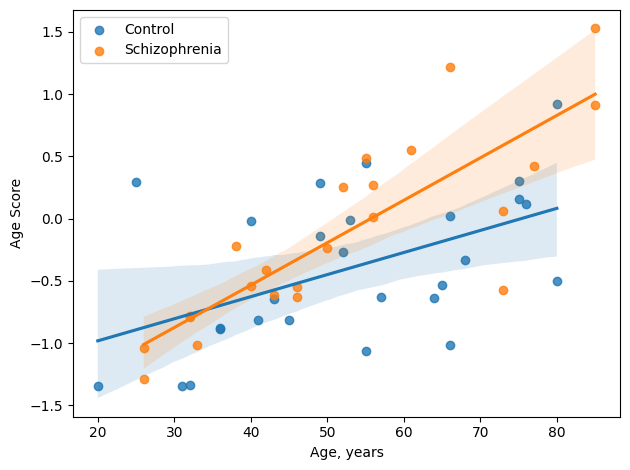

In [28]:
sns.regplot(data=df_plot.loc[:,:].query('Diagnosis == "CTL"'), x='Age', y='age_score', label='Control')
sns.regplot(data=df_plot.loc[:,:].query('Diagnosis != "CTL"'), x='Age', y='age_score', label='Schizophrenia')
plt.ylabel('Age Score')
plt.xlabel('Age, years')
plt.legend()

plt.tight_layout()
plt.show()
plt.close()

In [29]:
import statsmodels.formula.api as smf

df_plot["age_c"] = df_plot["Age"] - df_plot["Age"].mean()

model = smf.ols("age_score ~ age_c * C(Diagnosis, Treatment('CTL'))", data=df_plot.loc[:,:])
result = model.fit()
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:              age_score   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     16.19
Date:                Sun, 03 May 2026   Prob (F-statistic):           2.54e-07
Time:                        08:08:35   Log-Likelihood:                -32.953
No. Observations:                  50   AIC:                             73.91
Df Residuals:                      46   BIC:                             81.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [30]:
result.resid.to_csv('../results/Mendizabal.AgeScore.model.resid.csv')

ShapiroResult(statistic=0.9872166514396667, pvalue=0.861075758934021)


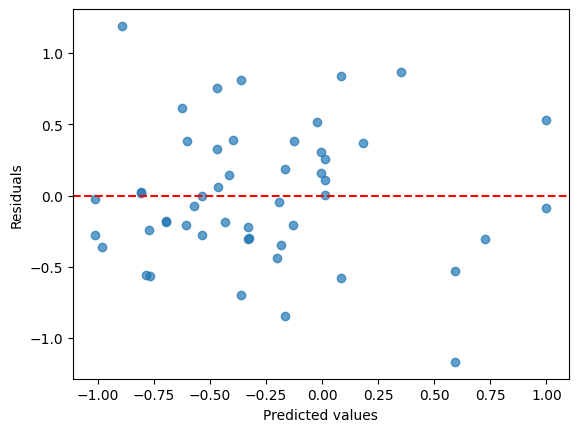

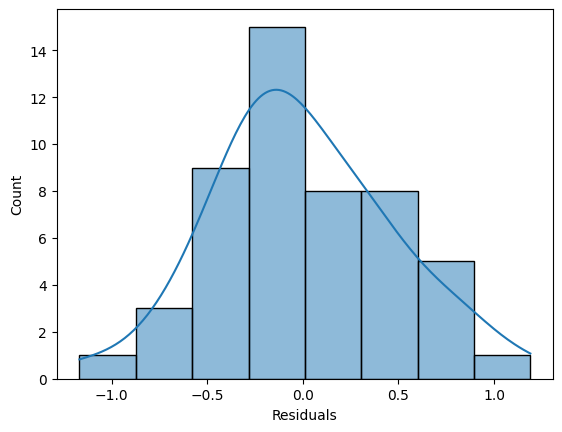

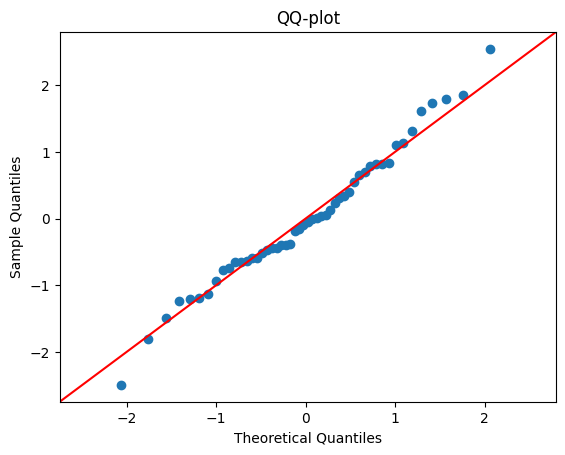

{'Lagrange multiplier statistic': 5.74104342985216, 'p-value': 0.12491167336247755, 'f-value': 1.9889608660688851, 'f p-value': 0.12880484071703346}


In [31]:
print(stats.shapiro(result.resid))

residuals = result.resid
fitted = result.fittedvalues

plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()
plt.close()

sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.show()
plt.close()

import statsmodels.api as sm

sm.qqplot(result.resid, line="45", fit=True)
plt.title("QQ-plot")
plt.show()
plt.close()

bp_test = het_breuschpagan(residuals, result.model.exog)

labels = ['Lagrange multiplier statistic', 
          'p-value', 
          'f-value', 
          'f p-value']

print(dict(zip(labels, bp_test)))